In [27]:
import pandas as pd  
from scan_spectrolyser import scan_helpers
from scan_spectrolyser import no3_calibrations
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from hampel import hampel
import os


# Data Processing

## Import all FP and Correct Timestamp

In [5]:
def get_fp_files(directory):
    # List all files in the directory ending with .fp
    return [directory + f for f in os.listdir(directory) if f.endswith('.fp')]

def import_all_scan_fp(directory):
    paths = get_fp_files(directory)
    files = [scan_helpers.import_scan_fp(path) for path in paths]

    for file in files:
        if (file.index[0] >= pd.to_datetime('03-09-2025 02:00')) and (file.index[0] <= pd.to_datetime('11-02-2025 02:00')):  # not very transerable code, shifts time if was in daylight savings
            file.index = file.index - pd.Timedelta('1h')

    return pd.concat(files).drop_duplicates().sort_values(by='Date/Time')

## Correct for Turbidity

In [6]:
rme = import_all_scan_fp('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/Reynolds Nitrate Monitoring/SCAN Data/RME/Readings/')
rme = rme['2025-01-23':] # only use data after install date
rme_corrected = scan_helpers.correct_turbidity(rme)

## Apply Calibrations

In [7]:
rme = scan_helpers.apply_calibrations(rme, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})
rme['two_wavelength_no3_mgl'] = (rme['two_wavelength'] * 3.6615-.0802)* 14/1000
rme['one_wavelength_no3_mgl'] = (rme['one_wavelength']*3.7314+.3704) * 14/1000
rme['second_derivative_no3_mgl'] = (rme['second_derivative'] * 42.7379-.2905)* 14/1000
rme['two_wavelength_no3_mgl_correct'] = (rme['two_wavelength'] * 5.2845-.07)* 14/1000
rme['one_wavelength_no3_mgl_correct'] = (rme['one_wavelength']*54.5596+.2994) * 14/1000
rme['second_derivative_no3_mgl_correct'] = (rme['second_derivative'] * 43.0776-.2904)* 14/1000

rme_corrected = scan_helpers.apply_calibrations(rme_corrected, [no3_calibrations.one_wavelength, no3_calibrations.two_wavelength, no3_calibrations.second_derivative], {no3_calibrations.second_derivative: {'output_calibrated':False}, no3_calibrations.two_wavelength: {'output_calibrated':False}, no3_calibrations.one_wavelength: {'output_calibrated':False}})
rme_corrected['two_wavelength_no3_mgl'] = (rme_corrected['two_wavelength'] * 3.6615-.0802)* 14/1000
rme_corrected['one_wavelength_no3_mgl'] = (rme_corrected['one_wavelength']*3.7314+.3704) * 14/1000
rme_corrected['second_derivative_no3_mgl'] = (rme_corrected['second_derivative'] * 42.7379-.2905)* 14/1000
rme_corrected['two_wavelength_no3_mgl_correct'] = (rme_corrected['two_wavelength'] * 5.2845-.07)* 14/1000
rme_corrected['one_wavelength_no3_mgl_correct'] = (rme_corrected['one_wavelength']*54.5596+.2994) * 14/1000
rme_corrected['second_derivative_no3_mgl_correct'] = (rme_corrected['second_derivative'] * 43.0776-.2904)* 14/1000
rme_corrected

,200.0,202.5,205.0,207.5,210.0,212.5,215.0,217.5,220.0,222.5,...,750.0,one_wavelength,two_wavelength,second_derivative,two_wavelength_no3_mgl,one_wavelength_no3_mgl,second_derivative_no3_mgl,two_wavelength_no3_mgl_correct,one_wavelength_no3_mgl_correct,second_derivative_no3_mgl_correct
Date/Time,,,,,,,,,,,,,,,,,,,,,
2025-01-23 12:25:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.387197,-1.498360,...,NaN,-0.387197,-5.445889,2.860563,-0.280285,-0.015041,1.707495,-0.403883,-0.291562,1.721101
2025-01-23 12:40:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.824093,-1.464754,...,NaN,-0.824093,-4.082574,0.185885,-0.210400,-0.037865,0.107154,-0.303021,-0.625279,0.108039
2025-01-23 12:55:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.065142,-0.519184,...,NaN,-1.065142,-4.227717,0.002149,-0.217840,-0.050457,-0.002781,-0.313759,-0.809401,-0.002770
2025-01-23 13:10:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.622361,-0.422517,...,NaN,-0.622361,-3.211542,0.202487,-0.165750,-0.027326,0.117087,-0.238580,-0.471189,0.118052
2025-01-23 13:25:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.457947,-0.400027,...,NaN,-0.457947,-3.060294,0.209805,-0.157997,-0.018737,0.121466,-0.227390,-0.345604,0.122465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-12 10:27:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.332939,2.365764,...,NaN,3.332939,3.439639,0.478224,0.175197,0.179297,0.282069,0.253495,2.550005,0.284345
2025-05-12 10:42:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.319429,2.343151,...,NaN,3.319429,3.435118,0.458203,0.174965,0.178591,0.270090,0.253160,2.539686,0.272270
2025-05-12 10:57:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.356284,2.362283,...,NaN,3.356284,3.473997,0.462185,0.176958,0.180517,0.272472,0.256037,2.567837,0.274672


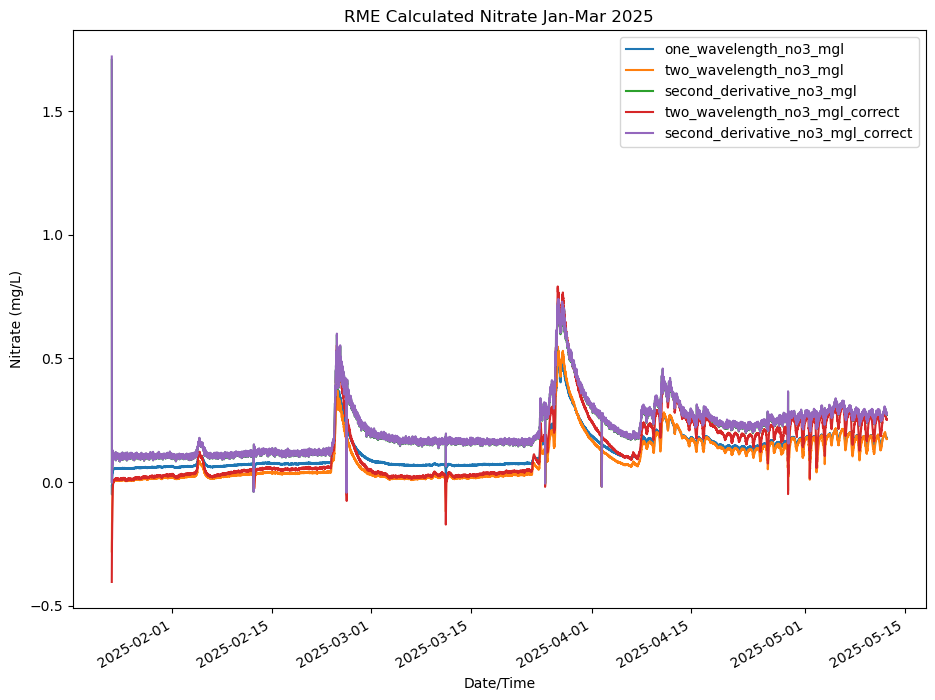

In [8]:
fig, ax = plt.subplots(figsize=(11, 8.5))

rme_corrected.plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl','two_wavelength_no3_mgl_correct', 'second_derivative_no3_mgl_correct'], title = 'RME Calculated Nitrate Jan-Mar 2025', ax=ax, ylabel='Nitrate (mg/L)')
#rme.plot(y=[220.00, 265.00], secondary_y=True, ylabel='Absorbance', ax=ax)
ax.yaxis.set_major_locator(MultipleLocator(.5))

## Cleanup Bad Values From Site Visits

<Axes: ylabel='Absorbance'>

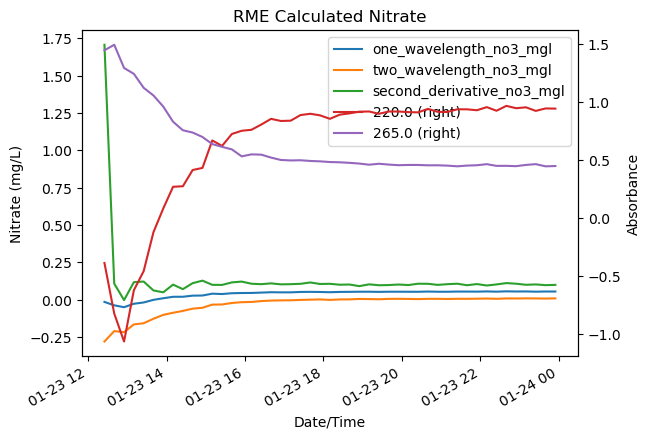

In [9]:
fig, ax= plt.subplots()

rme_corrected[:'2025-01-23'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected[:'2025-01-23'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')


- loooks like the initail turbidity cleared up around 1-23-25 at 18:00
- second_derivative method  rejected the turbidity, returned to normal almost immediately

<Axes: ylabel='Absorbance'>

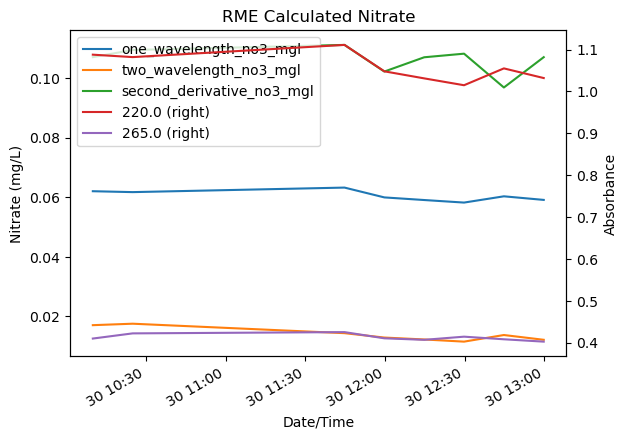

In [10]:
fig, ax= plt.subplots()

rme_corrected['2025-01-30 10:00':'2025-01-30 13:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected['2025-01-30 10:00':'2025-01-30 13:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- no spike in corrected data

<Axes: ylabel='Absorbance'>

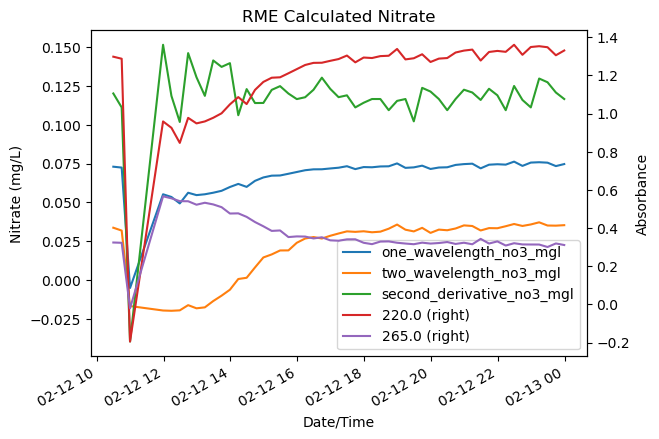

In [11]:
fig, ax= plt.subplots()

rme_corrected['2025-02-12 10:20':'2025-02-13 00:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected['2025-02-12 10:20':'2025-02-13 00:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- looks like readings bad from 10:20 to 18:00
- again, second_derivative clears up before two wavelength method and absorbance

<Axes: ylabel='Absorbance'>

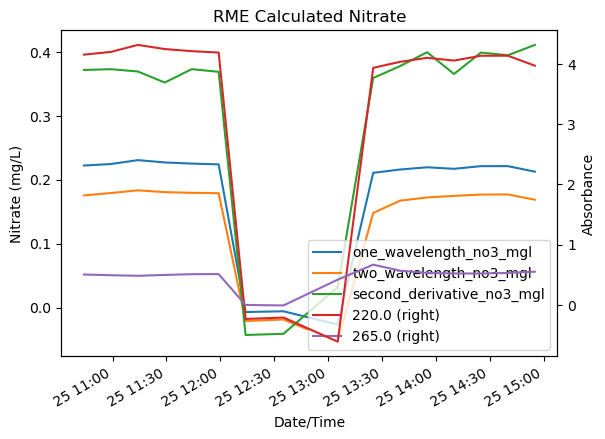

In [12]:
fig, ax= plt.subplots()

rme_corrected['2025-02-25 10:30':'2025-02-25 15:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected['2025-02-25 10:30':'2025-02-25 15:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- data are bad from 2025-02-25 12:00 to 13:30.
- this time 2nd derivative and two_ewavelength recover about the same

<Axes: ylabel='Absorbance'>

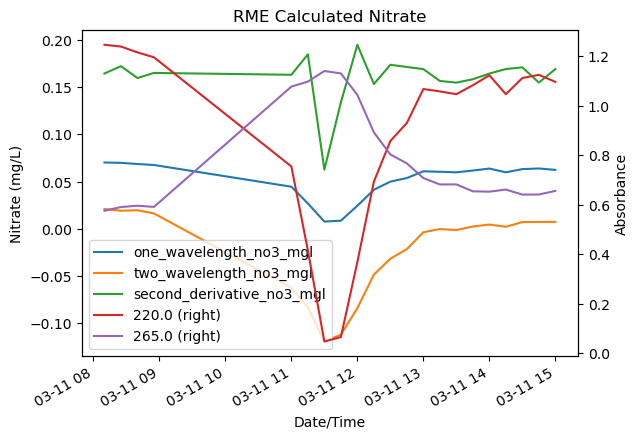

In [13]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-03-11 08:00':'2025-03-11 15:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-03-11 08:00':'2025-03-11 15:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- data are bad from 9:00 to 13:00

<Axes: ylabel='Absorbance'>

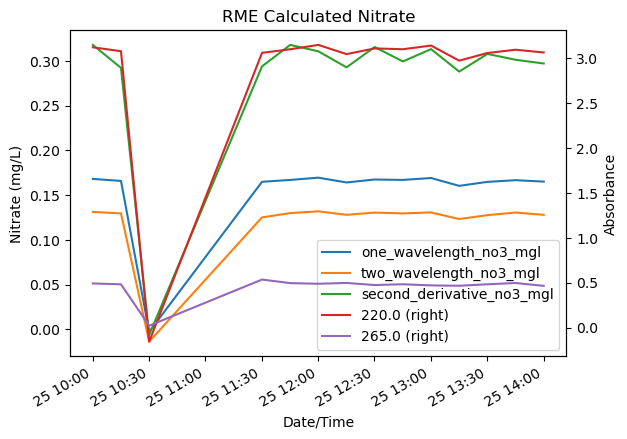

In [14]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-03-25 10:00':'2025-03-25 14:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-03-25 10:00':'2025-03-25 14:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- data bad from 10:10 to 11:30

<Axes: ylabel='Absorbance'>

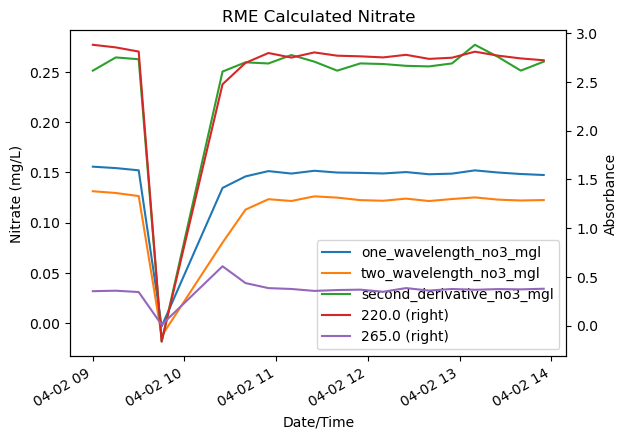

In [15]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-04-02 9:00':'2025-04-02 14:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-04-02 9:00':'2025-04-02 14:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

data bad from 9:30 to 10:30

<Axes: ylabel='Absorbance'>

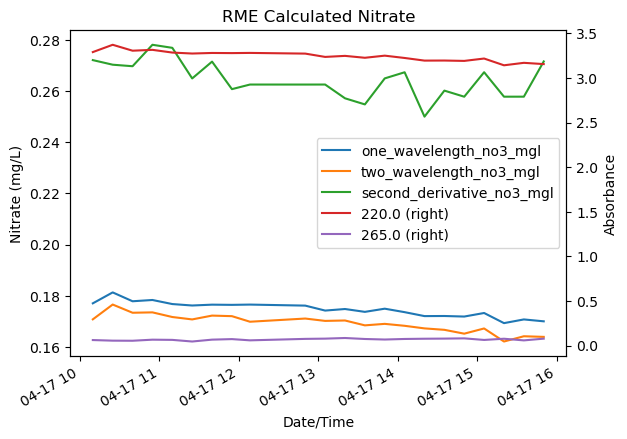

In [16]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-04-17 10:00':'2025-04-17 16:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-04-17 10:00':'2025-04-17 16:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- no bad data from this field visit

<Axes: ylabel='Absorbance'>

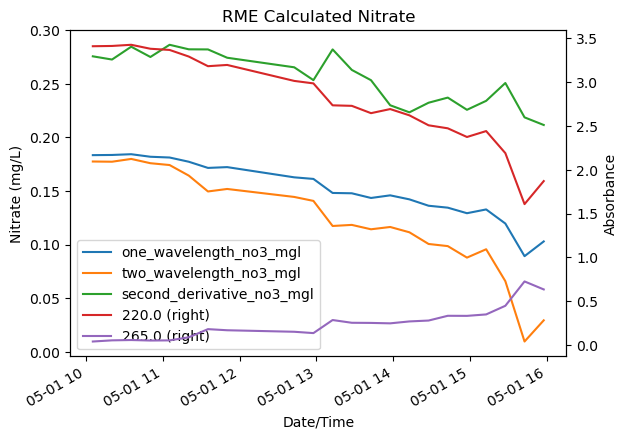

In [17]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-05-01 10:00':'2025-05-01 16:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-05-01 10:00':'2025-05-01 16:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

- also no bad data here

<Axes: ylabel='Absorbance'>

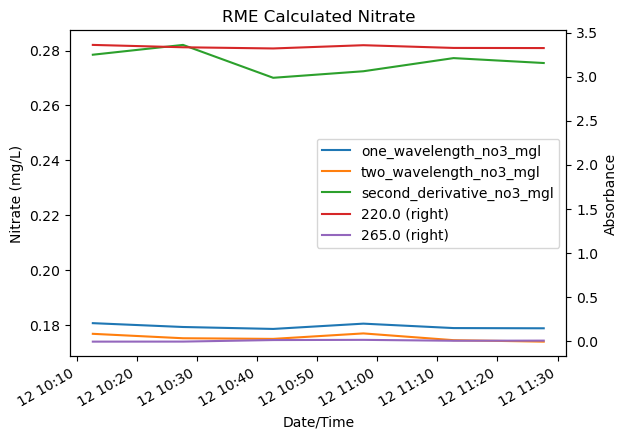

In [18]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-05-12 10:00':'2025-05-12 16:00'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-05-12 10:00':'2025-05-12 16:00'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

<Axes: ylabel='Absorbance'>

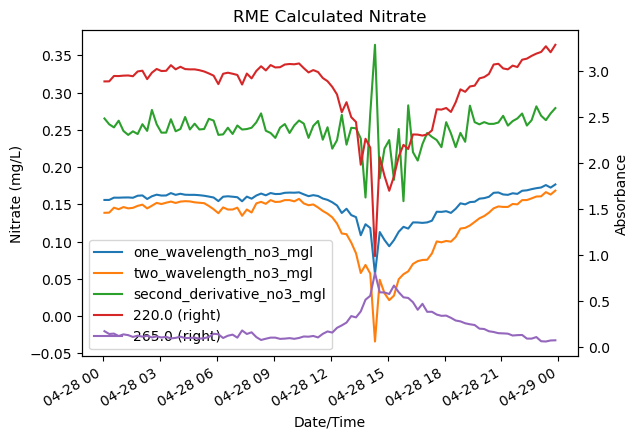

In [19]:
fig, ax= plt.subplots()

rme_corrected.loc['2025-04-28'].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate', ax=ax, ylabel='Nitrate (mg/L)')
rme_corrected.loc['2025-04-28'].plot(y=[220.00, 265.00], ax=ax, secondary_y=True, ylabel='Absorbance')

In [20]:
rme_bad = [
    ('2025-01-23 00:00', '2025-01-23 18:00'),
    ('2025-02-12 10:20', '2025-02-12 18:00'),
    ('2025-02-25 12:00', '2025-02-25 13:30'),
    ('2025-03-11 9:00', '2025-03-11 13:00'),
    ('2025-03-25 10:10', '2025-03-25 11:30'),
    ('2025-04-02 9:30', '2025-04-02 10:30'),
    ('2025-04-28 11:00', '2025-04-28 21:00'),

]
rme_mask = np.array([
    (rme.index >= start) & (rme.index <= end)
    for start, end in rme_bad
]).any(axis=0)

rme_cleaned = rme_corrected.loc[~rme_mask]
rme_cleaned

,200.0,202.5,205.0,207.5,210.0,212.5,215.0,217.5,220.0,222.5,...,750.0,one_wavelength,two_wavelength,second_derivative,two_wavelength_no3_mgl,one_wavelength_no3_mgl,second_derivative_no3_mgl,two_wavelength_no3_mgl_correct,one_wavelength_no3_mgl_correct,second_derivative_no3_mgl_correct
Date/Time,,,,,,,,,,,,,,,,,,,,,
2025-01-23 18:10:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857158,0.612866,...,NaN,0.857158,-0.010212,0.184406,-0.001646,0.049963,0.106269,-0.001736,0.658918,0.107147
2025-01-23 18:25:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.893012,0.617854,...,NaN,0.893012,0.052458,0.174396,0.001566,0.051836,0.100279,0.002901,0.686305,0.101110
2025-01-23 18:40:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.904527,0.614024,...,NaN,0.904527,0.061254,0.176402,0.002017,0.052438,0.101480,0.003552,0.695101,0.102320
2025-01-23 18:55:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.918794,0.625615,...,NaN,0.918794,0.114938,0.158420,0.004769,0.053183,0.090720,0.007523,0.705998,0.091475
2025-01-23 19:10:01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.920580,0.634453,...,NaN,0.920580,0.102590,0.178429,0.004136,0.053276,0.102693,0.006610,0.707362,0.103543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-12 10:27:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.332939,2.365764,...,NaN,3.332939,3.439639,0.478224,0.175197,0.179297,0.282069,0.253495,2.550005,0.284345
2025-05-12 10:42:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.319429,2.343151,...,NaN,3.319429,3.435118,0.458203,0.174965,0.178591,0.270090,0.253160,2.539686,0.272270
2025-05-12 10:57:42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.356284,2.362283,...,NaN,3.356284,3.473997,0.462185,0.176958,0.180517,0.272472,0.256037,2.567837,0.274672


### Replotting the whole time series of cleaned values:

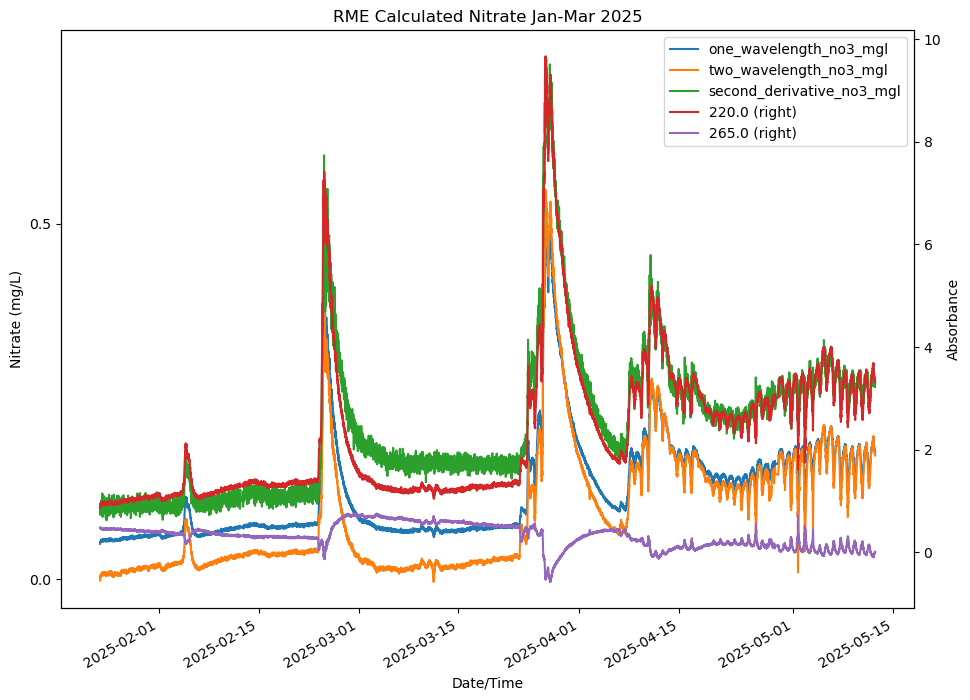

In [24]:
fig, ax = plt.subplots(figsize=(11, 8.5))

rme_cleaned.plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate Jan-Mar 2025', ax=ax, ylabel='Nitrate (mg/L)')
rme_cleaned.plot(y=[220.00, 265.00], secondary_y=True, ylabel='Absorbance', ax=ax)
ax.yaxis.set_major_locator(MultipleLocator(.5))

<Axes: ylabel='Absorbance'>

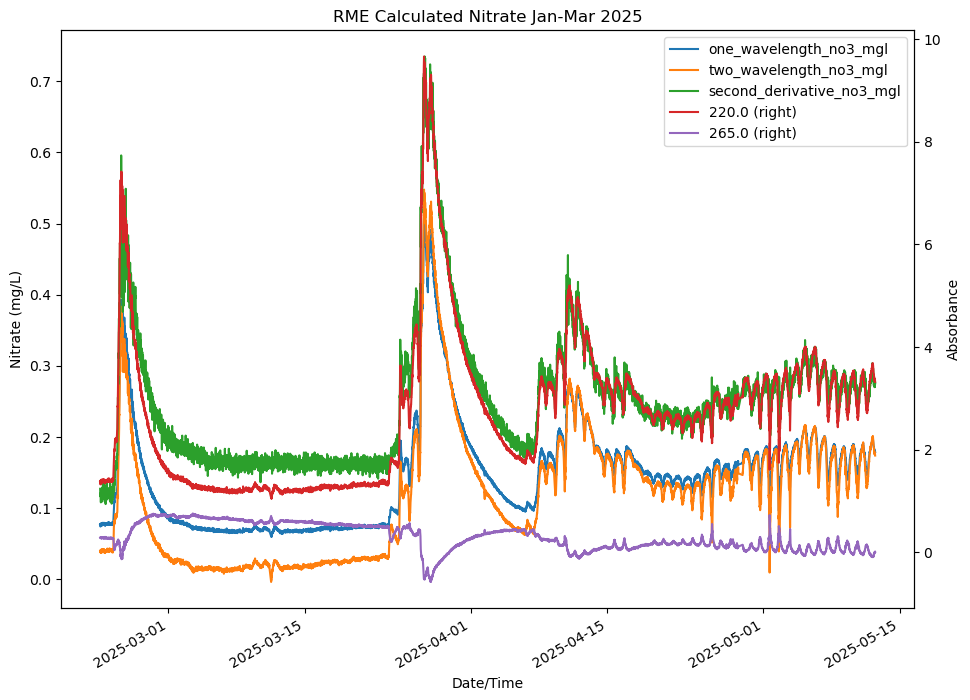

In [25]:
fig, ax = plt.subplots(figsize=(11, 8.5))

rme_cleaned['2/22/2025':].plot(y=['one_wavelength_no3_mgl', 'two_wavelength_no3_mgl', 'second_derivative_no3_mgl'], title = 'RME Calculated Nitrate Jan-Mar 2025', ax=ax, ylabel='Nitrate (mg/L)')
rme_cleaned['2/22/2025':].plot(y=[220.00, 265.00], secondary_y=True, ylabel='Absorbance', ax=ax)

In [26]:
rme_cleaned.to_csv('/Users/beneck/Library/CloudStorage/OneDrive-NortheasternUniversity/Boise Project/Data/Reynolds Nitrate Monitoring/SCAN Data/RME/Processed Data/rme_cleaned.csv')